In [1]:
import pandas as pd

eee = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\EEE.csv")

print(eee.shape)
print(eee.columns.tolist())

(2934, 32)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'clicks_dualpane', 'clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_page', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url']


In [3]:
demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                 'num_of_prev_attempts', 'studied_credits', 'disability']

assessment_cols = [f'ass_{i}_score' for i in range(1, 5)]

click_cols = ['clicks_dualpane', 'clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate',
              'clicks_oucontent', 'clicks_ouwiki', 'clicks_page', 'clicks_quiz',
              'clicks_resource', 'clicks_subpage', 'clicks_url']

selected_cols = demographics + assessment_cols + click_cols + ['final_result']

eee_sel = eee[selected_cols].copy()
print(eee_sel.shape)
eee_sel.head()

(2934, 24)


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,ass_1_score,ass_2_score,...,clicks_homepage,clicks_oucollaborate,clicks_oucontent,clicks_ouwiki,clicks_page,clicks_quiz,clicks_resource,clicks_subpage,clicks_url,final_result
0,M,Wales,Lower Than A Level,0-10%,35-55,0,30,N,NaN,NaN,...,15.0,0.0,17.0,0.0,0.0,4.0,0.0,2.0,0.0,Fail
1,M,North Western Region,A Level or Equivalent,60-70%,0-35,0,60,N,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Withdrawn
2,M,Wales,Lower Than A Level,0-10%,35-55,0,30,N,86.0,86.0,...,196.0,0.0,1102.0,327.0,0.0,150.0,7.0,12.0,26.0,Pass
3,M,West Midlands Region,A Level or Equivalent,40-50%,35-55,0,90,N,NaN,NaN,...,24.0,0.0,29.0,0.0,0.0,1.0,5.0,2.0,0.0,Withdrawn
4,M,Scotland,HE Qualification,90-100%,35-55,0,60,N,83.0,79.0,...,1178.0,3.0,2281.0,381.0,0.0,209.0,64.0,153.0,74.0,Pass


In [5]:
print("imd_band unique values:")
print(eee_sel['imd_band'].unique())
print()
print("imd_band NaN count:", eee_sel['imd_band'].isna().sum())
print()
print("NaN counts - assessment scores:")
print(eee_sel[assessment_cols].isna().sum())
print()
print("NaN counts - click columns:")
print(eee_sel[click_cols].isna().sum())

imd_band unique values:
['0-10%' '60-70%' '40-50%' '90-100%' '80-90%' '30-40%' '70-80%' '10-20'
 '50-60%' '20-30%' nan]

imd_band NaN count: 117

NaN counts - assessment scores:
ass_1_score     648
ass_2_score     900
ass_3_score    1069
ass_4_score    1233
dtype: int64

NaN counts - click columns:
clicks_dualpane         249
clicks_forumng          249
clicks_homepage         249
clicks_oucollaborate    249
clicks_oucontent        249
clicks_ouwiki           249
clicks_page             249
clicks_quiz             249
clicks_resource         249
clicks_subpage          249
clicks_url              249
dtype: int64


In [7]:
eee_sel['imd_band'] = eee_sel['imd_band'].replace('10-20', '10-20%')

imd_mode = eee_sel['imd_band'].mode()[0]
print("imd_band mode:", imd_mode)
eee_sel['imd_band'] = eee_sel['imd_band'].fillna(imd_mode)

print(eee_sel['imd_band'].unique())

click_nan_mask = eee_sel[click_cols].isna()
same_students = (click_nan_mask.sum(axis=1).isin([0, 11])).all()
print("All-or-nothing NaN pattern across clicks:", same_students)

eee_sel[assessment_cols] = eee_sel[assessment_cols].fillna(-1)
eee_sel[click_cols] = eee_sel[click_cols].fillna(0)

print(eee_sel.isna().sum().sum())

imd_band mode: 70-80%
['0-10%' '60-70%' '40-50%' '90-100%' '80-90%' '30-40%' '70-80%' '10-20%'
 '50-60%' '20-30%']
All-or-nothing NaN pattern across clicks: True
0


In [9]:
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
eee_sel['final_result'] = eee_sel['final_result'].map(final_result_map)

highest_ed_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
                     'HE Qualification', 'Post Graduate Qualification']
highest_ed_map = {v: i for i, v in enumerate(highest_ed_order)}
eee_sel['highest_education'] = eee_sel['highest_education'].map(highest_ed_map)

imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%',
             '60-70%', '70-80%', '80-90%', '90-100%']
imd_map = {v: i for i, v in enumerate(imd_order)}
eee_sel['imd_band'] = eee_sel['imd_band'].map(imd_map)

age_band_order = ['0-35', '35-55', '55<=']
age_band_map = {v: i for i, v in enumerate(age_band_order)}
eee_sel['age_band'] = eee_sel['age_band'].map(age_band_map)

eee_sel['gender'] = eee_sel['gender'].map({'M': 0, 'F': 1})
eee_sel['disability'] = eee_sel['disability'].map({'N': 0, 'Y': 1})

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
eee_sel['region'] = le.fit_transform(eee_sel['region'])

print(eee_sel.isna().sum().sum())
print(eee_sel.dtypes)

0
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
ass_1_score             float64
ass_2_score             float64
ass_3_score             float64
ass_4_score             float64
clicks_dualpane         float64
clicks_forumng          float64
clicks_homepage         float64
clicks_oucollaborate    float64
clicks_oucontent        float64
clicks_ouwiki           float64
clicks_page             float64
clicks_quiz             float64
clicks_resource         float64
clicks_subpage          float64
clicks_url              float64
final_result              int64
dtype: object


In [11]:
for col in click_cols:
    nonzero = (eee_sel[col] != 0).sum()
    unique_vals = eee_sel[col].nunique()
    print(f"{col}: {nonzero} nonzero / {unique_vals} unique values")

clicks_dualpane: 1059 nonzero / 27 unique values
clicks_forumng: 2452 nonzero / 811 unique values
clicks_homepage: 2682 nonzero / 699 unique values
clicks_oucollaborate: 1433 nonzero / 39 unique values
clicks_oucontent: 2642 nonzero / 1207 unique values
clicks_ouwiki: 1846 nonzero / 610 unique values
clicks_page: 343 nonzero / 17 unique values
clicks_quiz: 2527 nonzero / 279 unique values
clicks_resource: 2234 nonzero / 136 unique values
clicks_subpage: 2461 nonzero / 167 unique values
clicks_url: 2448 nonzero / 183 unique values


In [13]:
eee_sel['total_clicks'] = eee_sel[click_cols].sum(axis=1)
eee_sel = eee_sel.drop(columns=click_cols)

bin_cols = assessment_cols + ['total_clicks']

for col in bin_cols:
    binned = pd.qcut(eee_sel[col], q=4, duplicates='drop')
    n_bins = binned.nunique()
    print(f"{col}: {n_bins} bins")
    eee_sel[col] = binned.cat.codes

print()
print("Final shape:", eee_sel.shape)
print(eee_sel.columns.tolist())

ass_1_score: 4 bins
ass_2_score: 3 bins
ass_3_score: 3 bins
ass_4_score: 3 bins
total_clicks: 4 bins

Final shape: (2934, 14)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'final_result', 'total_clicks']


In [15]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import numpy as np

data = eee_sel.values.astype(float)
node_names = eee_sel.columns.tolist()

nodes = {name: GraphNode(name) for name in node_names}

assessment_cols_eee = [f'ass_{i}_score' for i in range(1, 5)]
demo_vars = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
             'num_of_prev_attempts', 'studied_credits', 'disability']
course_time_vars = assessment_cols_eee + ['total_clicks', 'final_result']

bk = BackgroundKnowledge()

# Rule 1
for ct in course_time_vars:
    for d in demo_vars:
        bk.add_forbidden_by_node(nodes[ct], nodes[d])

# Rule 2
for name in node_names:
    if name != 'gender':
        bk.add_forbidden_by_node(nodes[name], nodes['gender'])

# Rule 3
for i in range(1, 5):
    for j in range(1, 5):
        if j > i:
            bk.add_forbidden_by_node(nodes[f'ass_{j}_score'], nodes[f'ass_{i}_score'])

# Rule 4
for ct in course_time_vars:
    bk.add_forbidden_by_node(nodes[ct], nodes['studied_credits'])
    bk.add_forbidden_by_node(nodes[ct], nodes['num_of_prev_attempts'])

# Rule 5
for a in assessment_cols_eee:
    bk.add_forbidden_by_node(nodes['final_result'], nodes[a])

# Rule 6
for a in assessment_cols_eee:
    bk.add_forbidden_by_node(nodes[a], nodes['total_clicks'])

# Rule 7
bk.add_forbidden_by_node(nodes['final_result'], nodes['total_clicks'])

cg = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("PC complete.")
print("Number of edges:", cg.G.get_num_edges())

  0%|          | 0/14 [00:00<?, ?it/s]

PC complete.
Number of edges: 22


In [17]:
edges = cg.G.get_graph_edges()
for edge in edges:
    print(edge)

gender --> studied_credits
region --> highest_education
region --> imd_band
region --> ass_2_score
highest_education --> imd_band
age_band --> highest_education
age_band --> total_clicks
num_of_prev_attempts --> total_clicks
ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
ass_1_score --> final_result
total_clicks --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_4_score
total_clicks --> ass_2_score
ass_3_score --> ass_4_score
ass_3_score --> final_result
total_clicks --> ass_3_score
ass_4_score --> final_result
total_clicks --> ass_4_score
total_clicks --> final_result


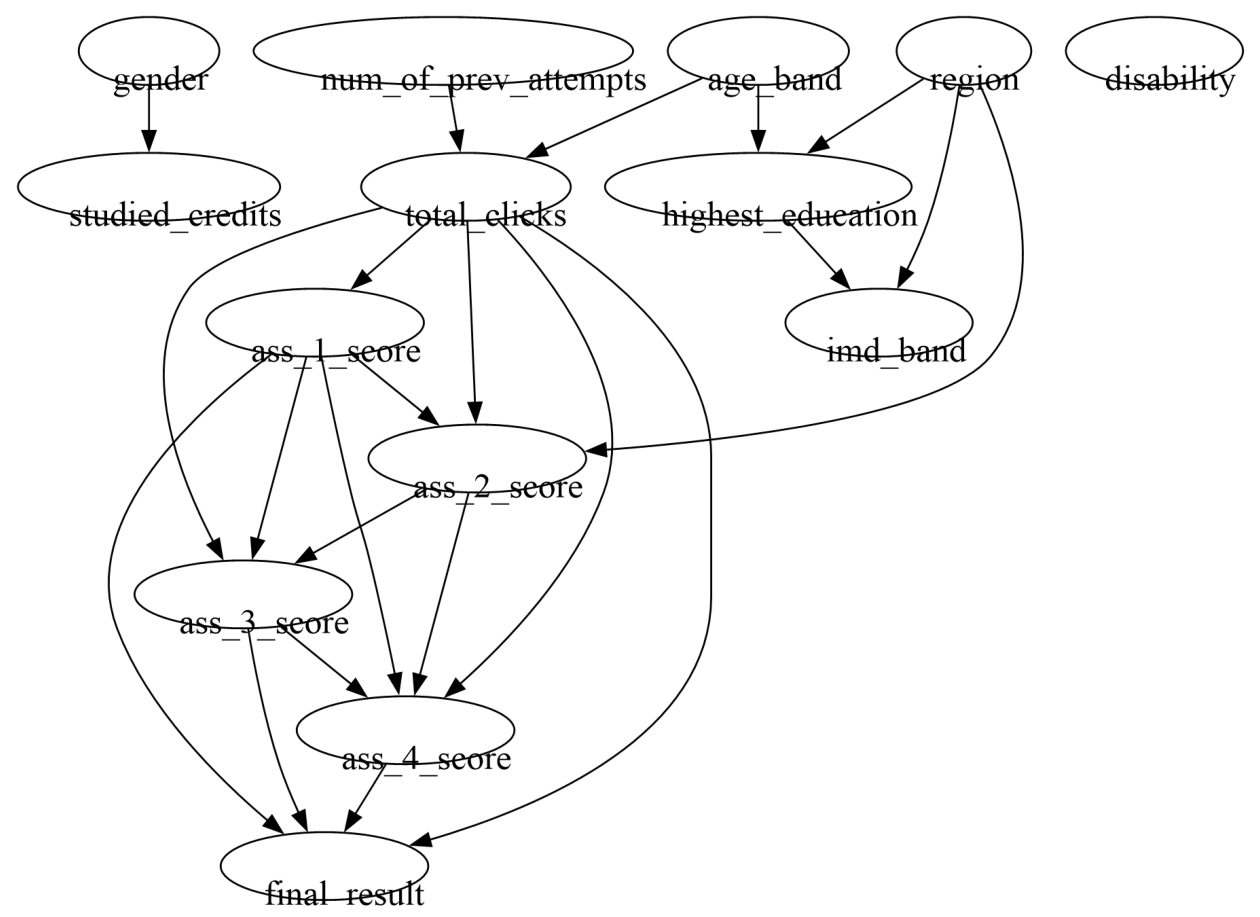

In [19]:
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

dot_path = r"C:\Users\Disha Sharma\.conda\envs\analytics\Library\bin\dot.exe"

pyd = GraphUtils.to_pydot(cg.G, labels=node_names)
png_data = pyd.create_png(prog=dot_path)

img = mpimg.imread(io.BytesIO(png_data))
plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis('off')
plt.show()

# Domain specific DAGs

In [32]:
## Student info vs final_result

In [34]:
df = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\EEE.csv")

print(df.shape)
print(list(df.columns))

(2934, 32)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'clicks_dualpane', 'clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_page', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url']


In [36]:
print(df[['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'final_result']].dtypes)
print(df[['gender', 'highest_education', 'final_result']].head(3))

gender               object
region               object
highest_education    object
imd_band             object
age_band             object
disability           object
final_result         object
dtype: object
  gender      highest_education final_result
0      M     Lower Than A Level         Fail
1      M  A Level or Equivalent    Withdrawn
2      M     Lower Than A Level         Pass


In [38]:
final_result_map = {'Withdrawn':0,'Fail':1,'Pass':2,'Distinction':3}
education_map = {'No Formal quals':0,'Lower Than A Level':1,'A Level or Equivalent':2,
                  'HE Qualification':3,'Post Graduate Qualification':4}
age_band_map = {'0-35':0,'35-55':1,'55<=':2}

print(df['imd_band'].unique())

df['final_result'] = df['final_result'].map(final_result_map)
df['highest_education'] = df['highest_education'].map(education_map)
df['age_band'] = df['age_band'].map(age_band_map)
df['gender'] = df['gender'].map({'M':0,'F':1})
df['disability'] = df['disability'].map({'N':0,'Y':1})
df['region'] = df['region'].astype('category').cat.codes

print(df[['gender', 'highest_education', 'age_band', 'final_result']].isnull().sum())

['0-10%' '60-70%' '40-50%' '90-100%' '80-90%' '30-40%' '70-80%' '10-20'
 '50-60%' '20-30%' nan]
gender               0
highest_education    0
age_band             0
final_result         0
dtype: int64


In [40]:
imd_map = {'0-10%':0,'10-20%':1,'10-20':1,'20-30%':2,'30-40%':3,'40-50%':4,
           '50-60%':5,'60-70%':6,'70-80%':7,'80-90%':8,'90-100%':9}

df['imd_band'] = df['imd_band'].map(imd_map)

print("NaN before mode-fill:", df['imd_band'].isnull().sum())

imd_mode = df['imd_band'].mode()[0]
df['imd_band'] = df['imd_band'].fillna(imd_mode)

print("NaN after mode-fill:", df['imd_band'].isnull().sum())
print("Mode used:", imd_mode)

NaN before mode-fill: 117
NaN after mode-fill: 0
Mode used: 7.0


In [42]:
demo_cols_eee = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                  'num_of_prev_attempts', 'studied_credits', 'disability']

dag1_data_eee = df[demo_cols_eee + ['final_result']].copy()

print(dag1_data_eee.shape)
print(dag1_data_eee.isnull().sum())

(2934, 9)
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64


In [44]:
node_names_dag1_eee = list(dag1_data_eee.columns)
nodes_dag1_eee = [GraphNode(name) for name in node_names_dag1_eee]

bk1_eee = BackgroundKnowledge()

gender_node_eee = nodes_dag1_eee[node_names_dag1_eee.index('gender')]
final_result_node_eee = nodes_dag1_eee[node_names_dag1_eee.index('final_result')]

# Rule 2: nothing causes gender (root)
for n in nodes_dag1_eee:
    if n != gender_node_eee:
        bk1_eee.add_forbidden_by_node(n, gender_node_eee)

# Rule 1 (generalized): final_result cannot cause any demographic
for n in nodes_dag1_eee:
    if n != final_result_node_eee:
        bk1_eee.add_forbidden_by_node(final_result_node_eee, n)

# Sanity check
highest_education_node_eee = nodes_dag1_eee[node_names_dag1_eee.index('highest_education')]
print("highest_education -> gender forbidden:", bk1_eee.is_forbidden(highest_education_node_eee, gender_node_eee))
print("final_result -> studied_credits forbidden:", bk1_eee.is_forbidden(final_result_node_eee, nodes_dag1_eee[node_names_dag1_eee.index('studied_credits')]))

highest_education -> gender forbidden: True
final_result -> studied_credits forbidden: True


In [46]:
data1_eee = dag1_data_eee.to_numpy()

cg1_eee = pc(data1_eee, alpha=0.05, indep_test='gsq', background_knowledge=bk1_eee, node_names=node_names_dag1_eee)

print("Number of edges:", cg1_eee.G.get_num_edges())

  0%|          | 0/9 [00:00<?, ?it/s]

Number of edges: 8


In [48]:
for edge in cg1_eee.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

gender [TAIL] -- [ARROW] studied_credits
region [TAIL] -- [ARROW] highest_education
region [TAIL] -- [TAIL] imd_band
region [TAIL] -- [ARROW] final_result
age_band [TAIL] -- [ARROW] highest_education
highest_education [TAIL] -- [ARROW] final_result
imd_band [TAIL] -- [ARROW] final_result
studied_credits [TAIL] -- [ARROW] final_result


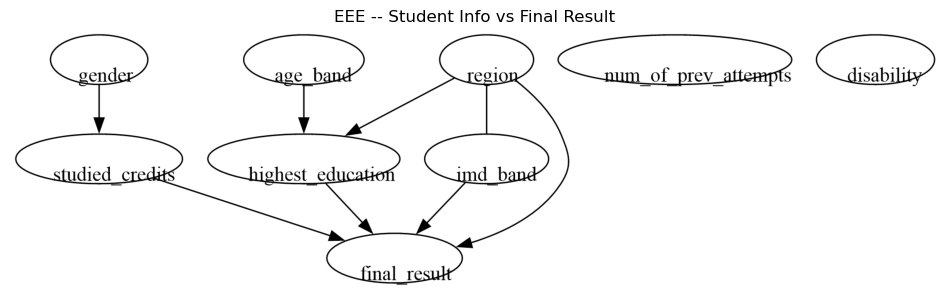

In [50]:
pyd1_eee = GraphUtils.to_pydot(cg1_eee.G, labels=node_names_dag1_eee)

for node in pyd1_eee.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes1_eee = pyd1_eee.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\EEE_DAG1_studentinfo_vs_finalresult.png", "wb") as f:
    f.write(png_bytes1_eee)

img1_eee = mpimg.imread(io.BytesIO(png_bytes1_eee), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img1_eee)
plt.axis('off')
plt.title("EEE -- Student Info vs Final Result")
plt.show()

## Disha, DAG 2 (EEE) — assessments vs final_result

In [53]:
ass_cols_eee = [f'ass_{i}_score' for i in range(1, 5)]

df[ass_cols_eee] = df[ass_cols_eee].fillna(-1)

dag2_data_eee = df[ass_cols_eee + ['final_result']].copy()

for col in ass_cols_eee:
    dag2_data_eee[col] = pd.qcut(dag2_data_eee[col], q=4, labels=False, duplicates='drop')

print(dag2_data_eee.shape)
print(dag2_data_eee.nunique())

(2934, 5)
ass_1_score     4
ass_2_score     3
ass_3_score     3
ass_4_score     3
final_result    4
dtype: int64


In [55]:
node_names_dag2_eee = list(dag2_data_eee.columns)
nodes_dag2_eee = [GraphNode(name) for name in node_names_dag2_eee]

bk2_eee = BackgroundKnowledge()

final_result_node2_eee = nodes_dag2_eee[node_names_dag2_eee.index('final_result')]

# Rule 5: final_result cannot cause any assessment
for n in nodes_dag2_eee:
    if n != final_result_node2_eee:
        bk2_eee.add_forbidden_by_node(final_result_node2_eee, n)

# Rule 3: sequential order -- ass_j cannot cause ass_i if j > i
for j in range(1, 5):
    for i in range(1, j):
        node_j = nodes_dag2_eee[node_names_dag2_eee.index(f'ass_{j}_score')]
        node_i = nodes_dag2_eee[node_names_dag2_eee.index(f'ass_{i}_score')]
        bk2_eee.add_forbidden_by_node(node_j, node_i)

# Sanity check
ass1_node_eee = nodes_dag2_eee[node_names_dag2_eee.index('ass_1_score')]
ass3_node_eee = nodes_dag2_eee[node_names_dag2_eee.index('ass_3_score')]
print("ass_3 -> ass_1 forbidden:", bk2_eee.is_forbidden(ass3_node_eee, ass1_node_eee))
print("final_result -> ass_1 forbidden:", bk2_eee.is_forbidden(final_result_node2_eee, ass1_node_eee))

ass_3 -> ass_1 forbidden: True
final_result -> ass_1 forbidden: True


In [57]:
data2_eee = dag2_data_eee.to_numpy()

cg2_eee = pc(data2_eee, alpha=0.05, indep_test='gsq', background_knowledge=bk2_eee, node_names=node_names_dag2_eee)

print("Number of edges:", cg2_eee.G.get_num_edges())

  0%|          | 0/5 [00:00<?, ?it/s]

Number of edges: 10


In [59]:
for edge in cg2_eee.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

ass_1_score [TAIL] -- [ARROW] ass_2_score
ass_1_score [TAIL] -- [ARROW] ass_3_score
ass_1_score [TAIL] -- [ARROW] ass_4_score
ass_1_score [TAIL] -- [ARROW] final_result
ass_2_score [TAIL] -- [ARROW] ass_3_score
ass_2_score [TAIL] -- [ARROW] ass_4_score
ass_2_score [TAIL] -- [ARROW] final_result
ass_3_score [TAIL] -- [ARROW] ass_4_score
ass_3_score [TAIL] -- [ARROW] final_result
ass_4_score [TAIL] -- [ARROW] final_result


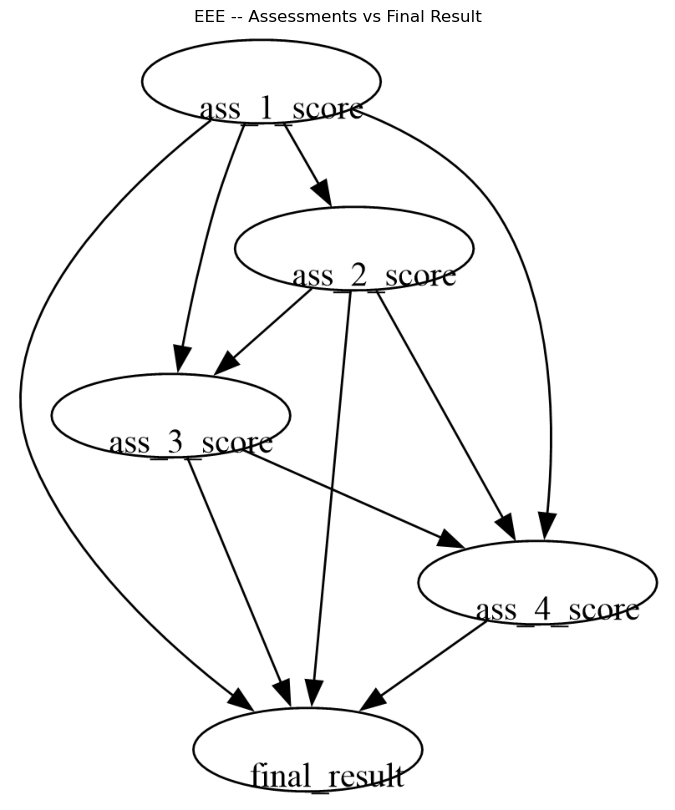

In [61]:
pyd2_eee = GraphUtils.to_pydot(cg2_eee.G, labels=node_names_dag2_eee)

for node in pyd2_eee.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes2_eee = pyd2_eee.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\EEE_DAG2_assessments_vs_finalresult.png", "wb") as f:
    f.write(png_bytes2_eee)

img2_eee = mpimg.imread(io.BytesIO(png_bytes2_eee), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img2_eee)
plt.axis('off')
plt.title("EEE -- Assessments vs Final Result")
plt.show()

## individual clicks vs final_result

In [64]:
raw_click_cols_eee = ['clicks_dualpane', 'clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate',
                       'clicks_oucontent', 'clicks_ouwiki', 'clicks_page', 'clicks_quiz',
                       'clicks_resource', 'clicks_subpage', 'clicks_url']

clicks_raw_eee = df[raw_click_cols_eee].fillna(0)

for col in raw_click_cols_eee:
    print(col, "nonzero:", (clicks_raw_eee[col] > 0).sum(), "unique:", clicks_raw_eee[col].nunique())

clicks_dualpane nonzero: 1059 unique: 27
clicks_forumng nonzero: 2452 unique: 811
clicks_homepage nonzero: 2682 unique: 699
clicks_oucollaborate nonzero: 1433 unique: 39
clicks_oucontent nonzero: 2642 unique: 1207
clicks_ouwiki nonzero: 1846 unique: 610
clicks_page nonzero: 343 unique: 17
clicks_quiz nonzero: 2527 unique: 279
clicks_resource nonzero: 2234 unique: 136
clicks_subpage nonzero: 2461 unique: 167
clicks_url nonzero: 2448 unique: 183


In [66]:
dag3_data_eee = clicks_raw_eee.copy()

for col in raw_click_cols_eee:
    dag3_data_eee[col] = pd.qcut(dag3_data_eee[col], q=4, labels=False, duplicates='drop')

dag3_data_eee['final_result'] = df['final_result'].values

print(dag3_data_eee.shape)
for col in dag3_data_eee.columns:
    print(col, dag3_data_eee[col].nunique())

(2934, 12)
clicks_dualpane 2
clicks_forumng 4
clicks_homepage 4
clicks_oucollaborate 2
clicks_oucontent 4
clicks_ouwiki 3
clicks_page 1
clicks_quiz 4
clicks_resource 4
clicks_subpage 4
clicks_url 4
final_result 4


In [68]:
node_names_dag3_eee = list(dag3_data_eee.columns)
nodes_dag3_eee = [GraphNode(name) for name in node_names_dag3_eee]

bk3_eee = BackgroundKnowledge()

final_result_node3_eee = nodes_dag3_eee[node_names_dag3_eee.index('final_result')]

# Rule 6 (per-column): final_result cannot cause any individual click variable
for n in nodes_dag3_eee:
    if n != final_result_node3_eee:
        bk3_eee.add_forbidden_by_node(final_result_node3_eee, n)

# Sanity check
clicks_resource_node_eee = nodes_dag3_eee[node_names_dag3_eee.index('clicks_resource')]
print("final_result -> clicks_resource forbidden:", bk3_eee.is_forbidden(final_result_node3_eee, clicks_resource_node_eee))

final_result -> clicks_resource forbidden: True


In [70]:
data3_eee = dag3_data_eee.to_numpy()

cg3_eee = pc(data3_eee, alpha=0.05, indep_test='gsq', background_knowledge=bk3_eee, node_names=node_names_dag3_eee)

print("Number of edges:", cg3_eee.G.get_num_edges())

  0%|          | 0/12 [00:00<?, ?it/s]

Number of edges: 28


In [72]:
for edge in cg3_eee.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

clicks_dualpane [TAIL] -- [TAIL] clicks_quiz
clicks_dualpane [TAIL] -- [ARROW] clicks_subpage
clicks_forumng [TAIL] -- [ARROW] clicks_homepage
clicks_oucollaborate [TAIL] -- [ARROW] clicks_forumng
clicks_quiz [TAIL] -- [ARROW] clicks_forumng
clicks_resource [TAIL] -- [ARROW] clicks_forumng
clicks_subpage [TAIL] -- [ARROW] clicks_forumng
clicks_url [TAIL] -- [ARROW] clicks_forumng
clicks_homepage [TAIL] -- [ARROW] clicks_oucontent
clicks_homepage [TAIL] -- [ARROW] clicks_ouwiki
clicks_quiz [TAIL] -- [ARROW] clicks_homepage
clicks_resource [TAIL] -- [ARROW] clicks_homepage
clicks_subpage [TAIL] -- [ARROW] clicks_homepage
clicks_url [TAIL] -- [ARROW] clicks_homepage
clicks_oucontent [TAIL] -- [ARROW] clicks_ouwiki
clicks_quiz [TAIL] -- [ARROW] clicks_oucontent
clicks_resource [TAIL] -- [ARROW] clicks_oucontent
clicks_subpage [TAIL] -- [ARROW] clicks_oucontent
clicks_url [TAIL] -- [ARROW] clicks_oucontent
clicks_oucontent [TAIL] -- [ARROW] final_result
clicks_url [TAIL] -- [ARROW] clicks_o

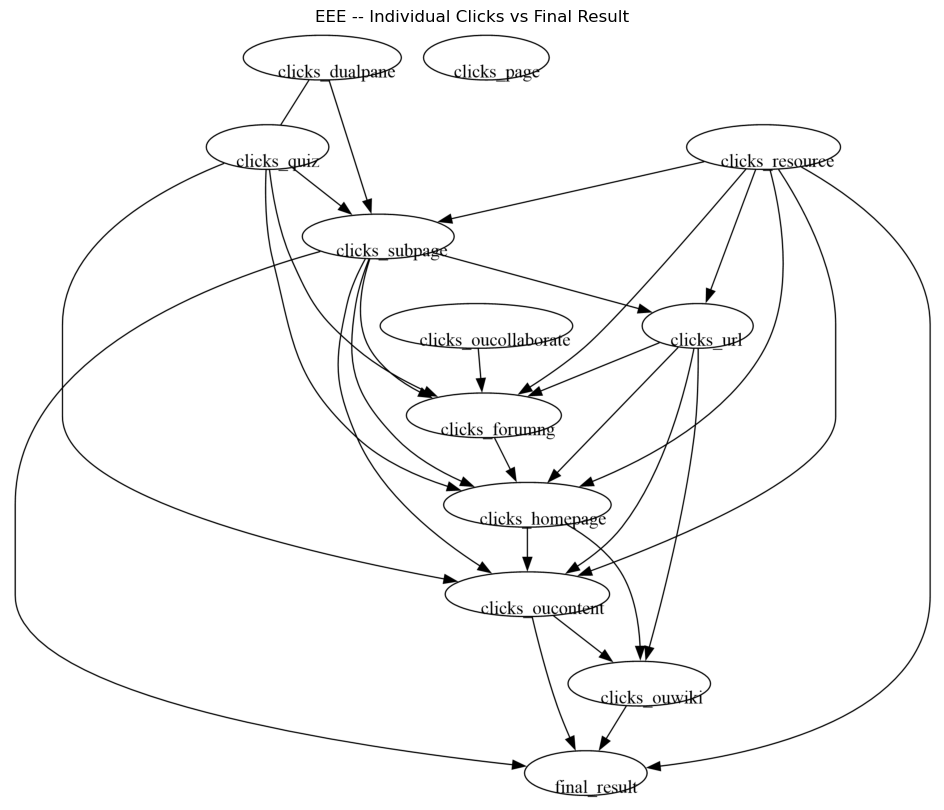

In [74]:
pyd3_eee = GraphUtils.to_pydot(cg3_eee.G, labels=node_names_dag3_eee)

for node in pyd3_eee.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes3_eee = pyd3_eee.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\EEE_DAG3_clicks_vs_finalresult.png", "wb") as f:
    f.write(png_bytes3_eee)

img3_eee = mpimg.imread(io.BytesIO(png_bytes3_eee), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img3_eee)
plt.axis('off')
plt.title("EEE -- Individual Clicks vs Final Result")
plt.show()

## assessments vs VLE clicks

In [77]:
df_eee_raw = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\EEE.csv")

print(df_eee_raw.shape)
df_eee_raw.head()

(2934, 32)


,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,clicks_forumng,clicks_homepage,clicks_oucollaborate,clicks_oucontent,clicks_ouwiki,clicks_page,clicks_quiz,clicks_resource,clicks_subpage,clicks_url
0,2013J,26915,M,Wales,Lower Than A Level,0-10%,35-55,0,30,N,...,23.0,15.0,0.0,17.0,0.0,0.0,4.0,0.0,2.0,0.0
1,2013J,32553,M,North Western Region,A Level or Equivalent,60-70%,0-35,0,60,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013J,35355,M,Wales,Lower Than A Level,0-10%,35-55,0,30,N,...,414.0,196.0,0.0,1102.0,327.0,0.0,150.0,7.0,12.0,26.0
3,2013J,40508,M,West Midlands Region,A Level or Equivalent,40-50%,35-55,0,90,N,...,30.0,24.0,0.0,29.0,0.0,0.0,1.0,5.0,2.0,0.0
4,2013J,42638,M,Scotland,HE Qualification,90-100%,35-55,0,60,N,...,1831.0,1178.0,3.0,2281.0,381.0,0.0,209.0,64.0,153.0,74.0


In [79]:
ass_cols_eee = [f"ass_{i}_score" for i in range(1, 5)]
click_cols_eee = [col for col in df_eee_raw.columns if col.startswith('clicks_')]

df_eee_sel = df_eee_raw[ass_cols_eee + click_cols_eee].copy()

# scores NaN -> -1, clicks NaN -> 0
df_eee_sel[ass_cols_eee] = df_eee_sel[ass_cols_eee].fillna(-1)
df_eee_sel[click_cols_eee] = df_eee_sel[click_cols_eee].fillna(0)

# quartile binning
for col in ass_cols_eee + click_cols_eee:
    df_eee_sel[col] = pd.qcut(df_eee_sel[col], q=4, labels=False, duplicates='drop')

print(df_eee_sel.shape)
df_eee_sel.nunique()

(2934, 15)


ass_1_score             4
ass_2_score             3
ass_3_score             3
ass_4_score             3
clicks_dualpane         2
clicks_forumng          4
clicks_homepage         4
clicks_oucollaborate    2
clicks_oucontent        4
clicks_ouwiki           3
clicks_page             1
clicks_quiz             4
clicks_resource         4
clicks_subpage          4
clicks_url              4
dtype: int64

In [81]:
df_eee_sel = df_eee_sel.drop(columns=['clicks_page'])
click_cols_eee = [col for col in click_cols_eee if col != 'clicks_page']

print(df_eee_sel.shape)
print(click_cols_eee)

(2934, 14)
['clicks_dualpane', 'clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url']


In [83]:
node_names_eee = list(df_eee_sel.columns)
data_eee = df_eee_sel.values

bk_eee = BackgroundKnowledge()

# Rule 3: sequential assessment order
for i in range(1, 5):
    for j in range(1, 5):
        if j > i:
            bk_eee.add_forbidden_by_node(
                GraphNode(f"ass_{j}_score"), GraphNode(f"ass_{i}_score")
            )

# Rule 6 variant: assessment scores cannot cause clicks
for ass in ass_cols_eee:
    for click in click_cols_eee:
        bk_eee.add_forbidden_by_node(GraphNode(ass), GraphNode(click))

cg_eee = pc(data_eee, 0.05, 'gsq', node_names=node_names_eee, background_knowledge=bk_eee)
print(cg_eee.G.get_num_edges())

  0%|          | 0/14 [00:00<?, ?it/s]

33


In [85]:
for edge in cg_eee.G.get_graph_edges():
    print(edge)

ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
clicks_homepage --> ass_1_score
clicks_oucontent --> ass_1_score
clicks_quiz --> ass_1_score
clicks_url --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_4_score
ass_3_score --> ass_4_score
clicks_resource --> ass_3_score
clicks_ouwiki --> ass_4_score
clicks_dualpane --- clicks_quiz
clicks_dualpane --> clicks_subpage
clicks_forumng --> clicks_homepage
clicks_forumng --> clicks_subpage
clicks_forumng --- clicks_url
clicks_homepage --> clicks_oucontent
clicks_homepage --> clicks_ouwiki
clicks_quiz --> clicks_homepage
clicks_resource --> clicks_homepage
clicks_subpage --> clicks_homepage
clicks_url --> clicks_homepage
clicks_oucontent --> clicks_ouwiki
clicks_quiz --> clicks_oucontent
clicks_resource --> clicks_oucontent
clicks_subpage --> clicks_oucontent
clicks_url --> clicks_oucontent
clicks_resource --> clicks_ouwiki
clicks_url --> clicks_ouwiki
clicks_quiz --> clicks_subpage
clicks_resou

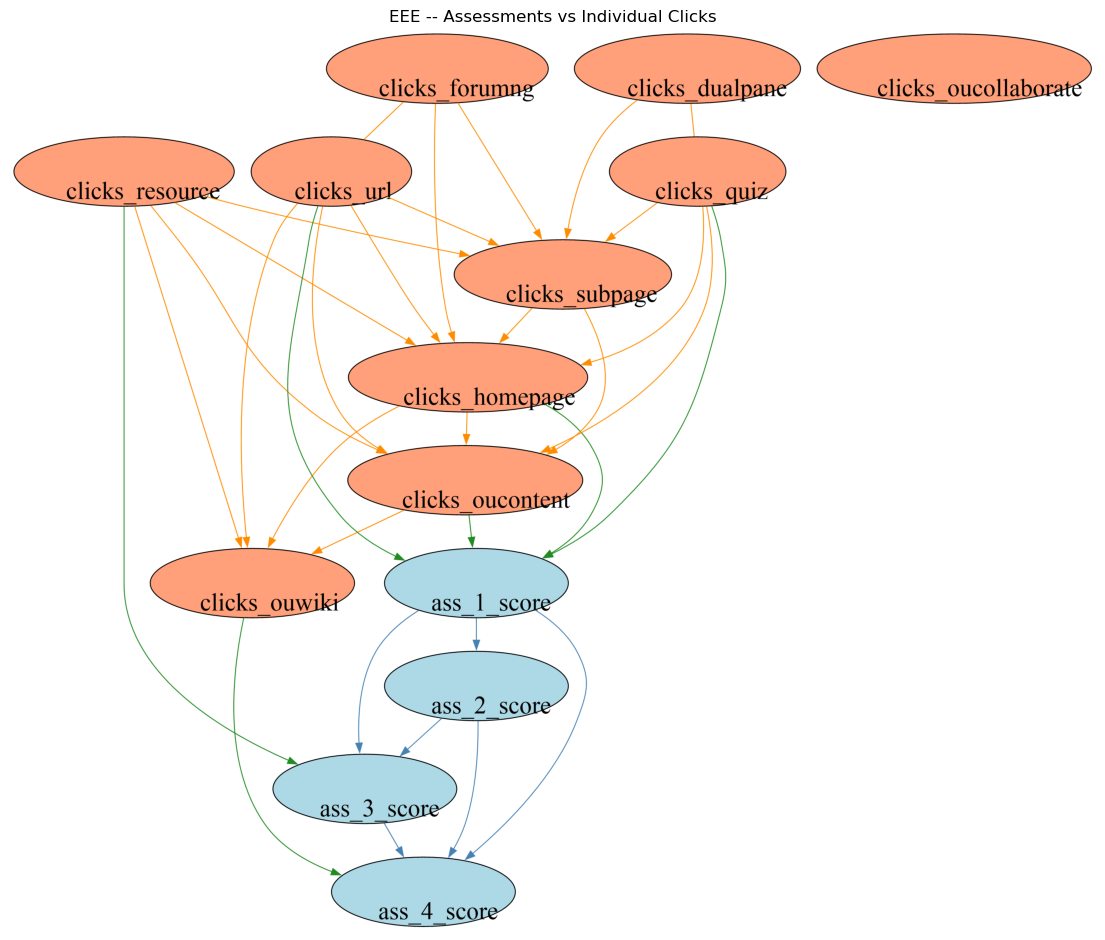

In [87]:
pyd_eee_assclicks = GraphUtils.to_pydot(cg_eee.G, labels=node_names_eee)

for node in pyd_eee_assclicks.get_nodes():
    name = node.get_name().strip('"')
    if name.isdigit():
        actual_name = node_names_eee[int(name)]
    else:
        continue
    if actual_name.startswith('ass_'):
        node.set_style('filled')
        node.set_fillcolor('lightblue')
    elif actual_name.startswith('clicks_'):
        node.set_style('filled')
        node.set_fillcolor('lightsalmon')
    node.set_fontsize('20')
    node.set_fixedsize('false')
    node.set_margin('0.3,0.20')

for edge in pyd_eee_assclicks.get_edges():
    src_idx = int(edge.get_source())
    dst_idx = int(edge.get_destination())
    src = node_names_eee[src_idx]
    dst = node_names_eee[dst_idx]
    if src.startswith('ass_') and dst.startswith('ass_'):
        edge.set_color('steelblue')
    elif src.startswith('clicks_') and dst.startswith('clicks_'):
        edge.set_color('darkorange')
    else:
        edge.set_color('forestgreen')

png_bytes_eee_assclicks = pyd_eee_assclicks.create_png(prog=dot_path)
with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\EEE_DAG4_assessments_vs_clicks.png", "wb") as f:
    f.write(png_bytes_eee_assclicks)
img_eee_assclicks = mpimg.imread(io.BytesIO(png_bytes_eee_assclicks), format='png')
plt.figure(figsize=(14, 12))
plt.imshow(img_eee_assclicks)
plt.axis('off')
plt.title("EEE -- Assessments vs Individual Clicks")
plt.show()